# KNN Classifier with Sentence-Transformers Embeddings

**Models:** `all-MiniLM-L6-v2` + `paraphrase-multilingual-mpnet-base-v2`  
**Search:** FAISS IndexFlatIP (exact) + IndexIVFFlat (approx, for large train)  
**Tasks:** queue (52 classes, macro-F1) | priority (5 cls, acc) | type (5 cls, acc)  
**Score:** 0.70·MacroF1(queue) + 0.15·Acc(priority) + 0.15·Acc(type)

## 0. Setup & Imports

In [3]:
pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 76.9 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [45]:
import json
import os
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import normalize
import joblib

try:
    import faiss
    print(f"faiss version: {faiss.__version__}")
    FAISS_OK = True
except ImportError:
    print("faiss not found — install: pip install faiss-cpu")
    FAISS_OK = False

from sentence_transformers import SentenceTransformer
print("sentence_transformers OK")

REPO = Path("/kaggle/working")
DATA_DIR  = Path("/kaggle/input/datasets/isaevsemyon/data-index")
EMB_DIR   = Path("/kaggle/working/embeddings")
PLOT_DIR  = Path("/kaggle/working/plots")
MODEL_DIR = Path("/kaggle/input/datasets/isaevsemyon/models")
RESULTS_FILE = Path("/kaggle/working/results_tfidf.json")

EMB_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

DATASET = "Tobi-Bueck/customer-support-tickets"
SEED = 42
TARGETS = ["queue", "priority", "type"]
K_VALUES = [2, 3, 5]

matplotlib.rcParams["figure.dpi"] = 120
print("Setup done.")

faiss version: 1.13.2
sentence_transformers OK
Setup done.


## 1. Load Dataset & Splits

In [7]:
print("Loading dataset...")
ds = load_dataset(DATASET)["train"]
df = ds.to_pandas()

# Fix type NaN
df["type"] = df["type"].fillna("Unknown")

def read_idx(path):
    return np.loadtxt(path, dtype=np.int64)

train_idx = read_idx(DATA_DIR / "train_idx.txt")
val_idx   = read_idx(DATA_DIR / "val_idx.txt")
test_idx  = read_idx(DATA_DIR / "test_idx.txt")

splits = {
    "train": df.iloc[train_idx].reset_index(drop=True),
    "val":   df.iloc[val_idx].reset_index(drop=True),
    "test":  df.iloc[test_idx].reset_index(drop=True),
}

for k, d in splits.items():
    print(f"{k}: {len(d)} rows")

def make_text(df_):
    return (df_["subject"].fillna("") + " [SEP] " + df_["body"].fillna("")).astype(str).tolist()

texts = {
    "train": make_text(splits["train"]),
    "val":   make_text(splits["val"]),
    "test":  make_text(splits["test"]),
}

labels = {
    split: {t: splits[split][t].astype(str).tolist() for t in TARGETS}
    for split in ["train", "val", "test"]
}

N_TRAIN = len(texts["train"])
print(f"\nText sample: {texts['train'][0][:120]}...")

Loading dataset...
train: 49412 rows
val: 6176 rows
test: 6177 rows

Text sample: Wesentlicher Sicherheitsvorfall [SEP] Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall me...


## 2. Encode with Sentence Transformers

In [8]:
def encode_and_save(model_name, model_tag, texts_dict, batch_size=256, max_length=256):
    """Encode all splits, save .npy, return dict of normalized embeddings."""
    print(f"\n{'='*60}")
    print(f"Encoding with: {model_name}  (tag={model_tag})")
    print(f"{'='*60}")

    model = SentenceTransformer(model_name)
    # Respect token limit
    model.max_seq_length = max_length

    embeddings = {}
    for split_name, txts in texts_dict.items():
        cache_path = EMB_DIR / f"{model_tag}_{split_name}.npy"
        if cache_path.exists():
            print(f"  [{split_name}] Loading cached: {cache_path}")
            emb = np.load(cache_path)
        else:
            print(f"  [{split_name}] Encoding {len(txts)} texts...")
            t0 = time.time()
            emb = model.encode(
                txts,
                batch_size=batch_size,
                show_progress_bar=True,
                normalize_embeddings=True,   # unit L2 norm → dot = cosine
                convert_to_numpy=True,
            )
            np.save(cache_path, emb)
            print(f"  [{split_name}] Done in {time.time()-t0:.1f}s. Shape={emb.shape}. Saved→{cache_path}")

        embeddings[split_name] = emb.astype(np.float32)
        print(f"  [{split_name}] shape={embeddings[split_name].shape}, norm~{np.linalg.norm(emb[0]):.3f}")

    del model
    return embeddings

In [9]:
# Model 1: fast English-focused
emb_mini = encode_and_save(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_tag="minilm",
    texts_dict=texts,
    batch_size=512,
    max_length=256,
)


Encoding with: sentence-transformers/all-MiniLM-L6-v2  (tag=minilm)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

  [train] Done in 81.3s. Shape=(49412, 384). Saved→/kaggle/working/embeddings/minilm_train.npy
  [train] shape=(49412, 384), norm~1.000
  [val] Encoding 6176 texts...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

  [val] Done in 11.0s. Shape=(6176, 384). Saved→/kaggle/working/embeddings/minilm_val.npy
  [val] shape=(6176, 384), norm~1.000
  [test] Encoding 6177 texts...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

  [test] Done in 11.2s. Shape=(6177, 384). Saved→/kaggle/working/embeddings/minilm_test.npy
  [test] shape=(6177, 384), norm~1.000


In [10]:
# Model 2: multilingual (handles DE tickets)
emb_mpnet = encode_and_save(
    model_name="sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    model_tag="mpnet_ml",
    texts_dict=texts,
    batch_size=256,
    max_length=256,
)


Encoding with: sentence-transformers/paraphrase-multilingual-mpnet-base-v2  (tag=mpnet_ml)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

  [train] Done in 372.2s. Shape=(49412, 768). Saved→/kaggle/working/embeddings/mpnet_ml_train.npy
  [train] shape=(49412, 768), norm~1.000
  [val] Encoding 6176 texts...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

  [val] Done in 46.9s. Shape=(6176, 768). Saved→/kaggle/working/embeddings/mpnet_ml_val.npy
  [val] shape=(6176, 768), norm~1.000
  [test] Encoding 6177 texts...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

  [test] Done in 46.6s. Shape=(6177, 768). Saved→/kaggle/working/embeddings/mpnet_ml_test.npy
  [test] shape=(6177, 768), norm~1.000


## 3. FAISS Index Building

In [36]:
def build_faiss_index(train_vecs, use_ivf=True, nprobe=32):
    """
    Returns (index, index_type_str).
    - IndexFlatIP: exact cosine (vectors already L2-normalised).
    - IndexIVFFlat: approx, faster for large train sets (>40k).
    """
    d = train_vecs.shape[1]          # embedding dim
    n = train_vecs.shape[0]

    if use_ivf and n > 40_000:
        nlist = max(64, int(np.sqrt(n)))   # ~222 for 49k
        print(f"  Building IndexIVFFlat: d={d}, nlist={nlist}, n={n}")
        quantizer = faiss.IndexFlatIP(d)
        index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)
        index.train(train_vecs)
        index.add(train_vecs)
        index.nprobe = nprobe
        idx_type = f"IVFFlat(nlist={nlist},nprobe={nprobe})"
    else:
        print(f"  Building IndexFlatIP: d={d}, n={n}")
        index = faiss.IndexFlatIP(d)
        index.add(train_vecs)
        idx_type = "FlatIP"

    print(f"  Index built: {idx_type}, ntotal={index.ntotal}")
    return index, idx_type


def knn_weighted_vote(index, query_vecs, train_labels, k):
    """
    Weighted voting by cosine similarity.
    Returns predicted labels for each query.
    """
    sims, indices = index.search(query_vecs, k)   # (n, k)
    preds = []
    for i in range(len(query_vecs)):
        neigh_idx = indices[i]      # shape (k,)
        neigh_sim = sims[i]         # cosine similarities
        # Shift to non-negative (cosine can be slightly negative)
        weights = np.maximum(neigh_sim, 0)
        if weights.sum() == 0:
            weights = np.ones(k)
        # Weighted vote
        vote: dict = {}
        for j, idx in enumerate(neigh_idx):
            lbl = train_labels[idx]
            vote[lbl] = vote.get(lbl, 0.0) + float(weights[j])
        preds.append(max(vote, key=vote.get))
    return np.array(preds)


def composite_score(queue_f1, prio_acc, type_acc):
    return 0.70 * queue_f1 + 0.15 * prio_acc + 0.15 * type_acc


def evaluate_knn(index, query_vecs, train_labels_dict, query_labels_dict, k_values, split_name):
    """Evaluate KNN for all targets and k values."""
    results = {}
    for k in k_values:
        row = {}
        print(f"\n  --- k={k} [{split_name}] ---")
        preds_all = {}
        for target in TARGETS:
            preds = knn_weighted_vote(
                index, query_vecs,
                train_labels_dict[target], k
            )
            true = np.array(query_labels_dict[target])
            acc  = float(accuracy_score(true, preds))
            mf1  = float(f1_score(true, preds, average="macro", zero_division=0))
            row[target] = {"accuracy": round(acc, 4), "macro_f1": round(mf1, 4)}
            preds_all[target] = preds
            print(f"    {target:10s}: acc={acc:.4f}  macro_f1={mf1:.4f}")

        cs = composite_score(
            row["queue"]["macro_f1"],
            row["priority"]["accuracy"],
            row["type"]["accuracy"]
        )
        row["composite_score"] = round(cs, 4)
        print(f"    composite={cs:.4f}")
        results[k] = {"metrics": row, "preds": preds_all}
    return results

## 4. KNN — all-MiniLM-L6-v2

In [37]:
# Build both exact and IVF indexes for MiniLM
train_vecs_mini = emb_mini["train"]

print("=== MiniLM: IndexFlatIP (exact) ===")
idx_mini_flat, idx_type_mini_flat = build_faiss_index(train_vecs_mini, use_ivf=False)

print("\n=== MiniLM: IndexIVFFlat (approx) ===")
idx_mini_ivf, idx_type_mini_ivf = build_faiss_index(train_vecs_mini, use_ivf=True)

=== MiniLM: IndexFlatIP (exact) ===
  Building IndexFlatIP: d=384, n=49412
  Index built: FlatIP, ntotal=49412

=== MiniLM: IndexIVFFlat (approx) ===
  Building IndexIVFFlat: d=384, nlist=222, n=49412
  Index built: IVFFlat(nlist=222,nprobe=32), ntotal=49412


In [38]:
# Evaluate on VAL — exact
print("\n====== MiniLM / FlatIP / VAL ======")
mini_flat_val = evaluate_knn(
    idx_mini_flat,
    emb_mini["val"],
    labels["train"],
    labels["val"],
    K_VALUES,
    "val"
)


====== MiniLM / FlatIP / VAL ======

  --- k=2 [val] ---
    queue     : acc=0.7916  macro_f1=0.9111
    priority  : acc=0.8196  macro_f1=0.8659
    type      : acc=0.9053  macro_f1=0.8976
    composite=0.8965

  --- k=3 [val] ---
    queue     : acc=0.7238  macro_f1=0.8785
    priority  : acc=0.7539  macro_f1=0.8089
    type      : acc=0.8729  macro_f1=0.8627
    composite=0.8590

  --- k=5 [val] ---
    queue     : acc=0.6750  macro_f1=0.8412
    priority  : acc=0.7060  macro_f1=0.7613
    type      : acc=0.8572  macro_f1=0.8429
    composite=0.8233


In [39]:
# Evaluate on VAL — approx IVF
print("\n====== MiniLM / IVFFlat / VAL ======")
mini_ivf_val = evaluate_knn(
    idx_mini_ivf,
    emb_mini["val"],
    labels["train"],
    labels["val"],
    K_VALUES,
    "val"
)


====== MiniLM / IVFFlat / VAL ======

  --- k=2 [val] ---
    queue     : acc=0.7902  macro_f1=0.9103
    priority  : acc=0.8182  macro_f1=0.8649
    type      : acc=0.9045  macro_f1=0.8963
    composite=0.8956

  --- k=3 [val] ---
    queue     : acc=0.7228  macro_f1=0.8778
    priority  : acc=0.7519  macro_f1=0.8068
    type      : acc=0.8716  macro_f1=0.8612
    composite=0.8580

  --- k=5 [val] ---
    queue     : acc=0.6737  macro_f1=0.8386
    priority  : acc=0.7034  macro_f1=0.7567
    type      : acc=0.8557  macro_f1=0.8414
    composite=0.8209


In [40]:
# Best k on val → evaluate on TEST
best_k_mini = max(
    K_VALUES,
    key=lambda k: mini_flat_val[k]["metrics"]["composite_score"]
)
print(f"Best k for MiniLM (flat): {best_k_mini}")

print("\n====== MiniLM / FlatIP / TEST ======")
mini_flat_test = evaluate_knn(
    idx_mini_flat,
    emb_mini["test"],
    labels["train"],
    labels["test"],
    [best_k_mini],
    "test"
)

Best k for MiniLM (flat): 2

====== MiniLM / FlatIP / TEST ======

  --- k=2 [test] ---
    queue     : acc=0.7829  macro_f1=0.9006
    priority  : acc=0.8166  macro_f1=0.8573
    type      : acc=0.9072  macro_f1=0.9026
    composite=0.8890


## 5. KNN — paraphrase-multilingual-mpnet-base-v2

In [41]:
train_vecs_mpnet = emb_mpnet["train"]

print("=== MPNet-ML: IndexFlatIP (exact) ===")
idx_mpnet_flat, idx_type_mpnet_flat = build_faiss_index(train_vecs_mpnet, use_ivf=False)

print("\n=== MPNet-ML: IndexIVFFlat (approx) ===")
idx_mpnet_ivf, idx_type_mpnet_ivf = build_faiss_index(train_vecs_mpnet, use_ivf=True)

=== MPNet-ML: IndexFlatIP (exact) ===
  Building IndexFlatIP: d=768, n=49412
  Index built: FlatIP, ntotal=49412

=== MPNet-ML: IndexIVFFlat (approx) ===
  Building IndexIVFFlat: d=768, nlist=222, n=49412
  Index built: IVFFlat(nlist=222,nprobe=32), ntotal=49412


In [42]:
print("\n====== MPNet-ML / FlatIP / VAL ======")
mpnet_flat_val = evaluate_knn(
    idx_mpnet_flat,
    emb_mpnet["val"],
    labels["train"],
    labels["val"],
    K_VALUES,
    "val"
)

best_k_mpnet = max(
    K_VALUES,
    key=lambda k: mpnet_flat_val[k]["metrics"]["composite_score"]
)
print(f"\nBest k for MPNet-ML (flat): {best_k_mpnet}")

print("\n====== MPNet-ML / FlatIP / TEST ======")
mpnet_flat_test = evaluate_knn(
    idx_mpnet_flat,
    emb_mpnet["test"],
    labels["train"],
    labels["test"],
    [best_k_mpnet],
    "test"
)


====== MPNet-ML / FlatIP / VAL ======

  --- k=2 [val] ---
    queue     : acc=0.8488  macro_f1=0.9506
    priority  : acc=0.8787  macro_f1=0.9159
    type      : acc=0.9475  macro_f1=0.9473
    composite=0.9394

  --- k=3 [val] ---
    queue     : acc=0.7970  macro_f1=0.9204
    priority  : acc=0.8119  macro_f1=0.8558
    type      : acc=0.9210  macro_f1=0.9196
    composite=0.9042

  --- k=5 [val] ---
    queue     : acc=0.7349  macro_f1=0.8778
    priority  : acc=0.7596  macro_f1=0.7914
    type      : acc=0.9016  macro_f1=0.8985
    composite=0.8636

Best k for MPNet-ML (flat): 2

====== MPNet-ML / FlatIP / TEST ======

  --- k=2 [test] ---
    queue     : acc=0.8490  macro_f1=0.9503
    priority  : acc=0.8711  macro_f1=0.9049
    type      : acc=0.9441  macro_f1=0.9445
    composite=0.9375


## 6. Comparison Table: Val Results

'          model  k  queue_macro_f1  priority_acc  type_acc  composite\nMPNet-ML-FlatIP  2          0.9506        0.8787    0.9475     0.9394\nMPNet-ML-FlatIP  3          0.9204        0.8119    0.9210     0.9042\n  MiniLM-FlatIP  2          0.9111        0.8196    0.9053     0.8965\n MiniLM-IVFFlat  2          0.9103        0.8182    0.9045     0.8956\nMPNet-ML-FlatIP  5          0.8778        0.7596    0.9016     0.8636\n  MiniLM-FlatIP  3          0.8785        0.7539    0.8729     0.8590\n MiniLM-IVFFlat  3          0.8778        0.7519    0.8716     0.8580\n  MiniLM-FlatIP  5          0.8412        0.7060    0.8572     0.8233\n MiniLM-IVFFlat  5          0.8386        0.7034    0.8557     0.8209'

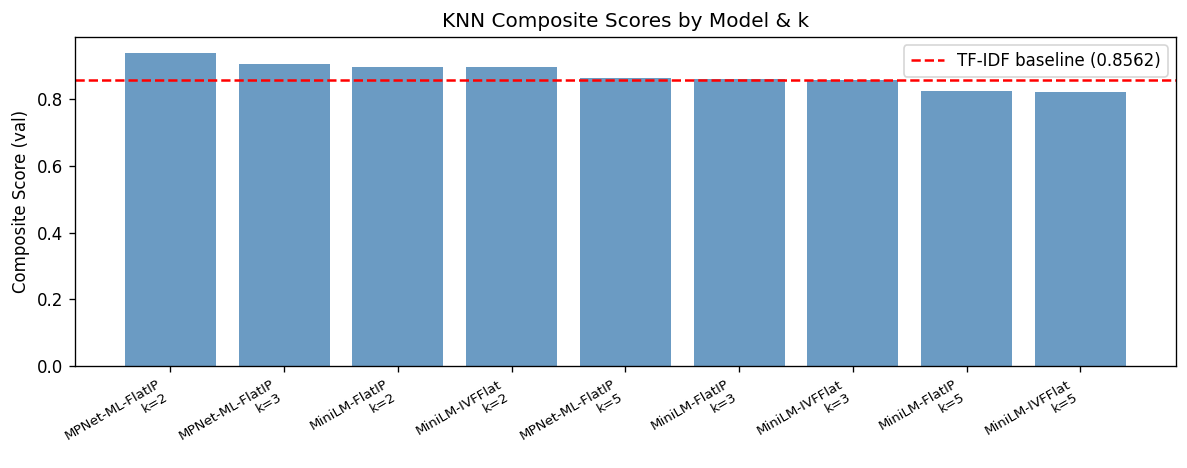

In [43]:
rows = []
for k in K_VALUES:
    for model_tag, res in [("MiniLM-FlatIP", mini_flat_val), ("MiniLM-IVFFlat", mini_ivf_val), ("MPNet-ML-FlatIP", mpnet_flat_val)]:
        m = res[k]["metrics"]
        rows.append({
            "model": model_tag,
            "k": k,
            "queue_macro_f1": m["queue"]["macro_f1"],
            "priority_acc":   m["priority"]["accuracy"],
            "type_acc":       m["type"]["accuracy"],
            "composite":      m["composite_score"],
        })

compare_df = pd.DataFrame(rows).sort_values("composite", ascending=False)
display(compare_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(compare_df))
ax.bar(x, compare_df["composite"], color="steelblue", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r['model']}\nk={r['k']}" for _, r in compare_df.iterrows()],
    rotation=30, ha="right", fontsize=8
)
ax.set_ylabel("Composite Score (val)")
ax.set_title("KNN Composite Scores by Model & k")
ax.axhline(0.8562, color="red", linestyle="--", label="TF-IDF baseline (0.8562)")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "knn_compare_val.png", dpi=150)
plt.show()

## 7. Hybrid: TF-IDF Decision Scores × 0.4 + Embedding Similarity × 0.6

In [46]:
# Load saved TF-IDF models: dict with keys "vectorizer" and "classifier"
tfidf_pipelines = {}
for target in TARGETS:
    path = MODEL_DIR / f"best_{target}_LinearSVC.joblib"
    if path.exists():
        tfidf_pipelines[target] = joblib.load(path)
        print(f"Loaded TF-IDF model for {target} from {path}")
    else:
        print(f"[WARN] Not found: {path}  — skipping hybrid for {target}")

# Verify structure
if tfidf_pipelines:
    sample = tfidf_pipelines.get("queue", {})
    print("\nSaved model keys:", list(sample.keys()))
    print("Vectorizer:", type(sample.get("vectorizer")))
    print("Classifier:", type(sample.get("classifier")))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.7.2 when using version 1.6.1. This might lead to breaking code or in

Loaded TF-IDF model for queue from /kaggle/input/datasets/isaevsemyon/models/best_queue_LinearSVC.joblib
Loaded TF-IDF model for priority from /kaggle/input/datasets/isaevsemyon/models/best_priority_LinearSVC.joblib
Loaded TF-IDF model for type from /kaggle/input/datasets/isaevsemyon/models/best_type_LinearSVC.joblib

Saved model keys: ['vectorizer', 'classifier']
Vectorizer: <class 'sklearn.feature_extraction.text.TfidfVectorizer'>
Classifier: <class 'sklearn.svm._classes.LinearSVC'>


In [47]:
def hybrid_predict(
    split_name, emb_index, query_emb,
    train_labels_dict, query_labels_dict,
    tfidf_models, query_texts,
    k=10, alpha_tfidf=0.4, alpha_emb=0.6
):
    """
    Hybrid ensemble:
      score(class c | query q) = alpha_tfidf * tfidf_softmax_score(c|q)
                                + alpha_emb  * emb_knn_weighted_vote(c|q)

    tfidf_models: dict[target] = {"vectorizer": ..., "classifier": LinearSVC}
    LinearSVC.decision_function → margin scores → softmax → proba proxy
    """
    from scipy.special import softmax as sp_softmax

    results = {}
    n_queries = len(query_emb)

    # FAISS: get top-k neighbours once (shared across targets)
    sims, indices = emb_index.search(query_emb, k)   # (n, k)

    for target in TARGETS:
        true_labels = np.array(query_labels_dict[target])
        train_lbls  = train_labels_dict[target]

        # ---- Embedding vote distribution ----
        classes = sorted(set(train_lbls))
        cls2idx = {c: i for i, c in enumerate(classes)}
        n_cls   = len(classes)

        emb_votes = np.zeros((n_queries, n_cls), dtype=np.float32)
        for i in range(n_queries):
            for j in range(k):
                w   = max(float(sims[i, j]), 0.0)
                lbl = train_lbls[int(indices[i, j])]
                if lbl in cls2idx:
                    emb_votes[i, cls2idx[lbl]] += w

        # Row-normalise
        row_sum = emb_votes.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1.0
        emb_proba = emb_votes / row_sum   # (n, n_cls)

        # ---- TF-IDF decision scores → softmax proba proxy ----
        if target not in tfidf_models or alpha_tfidf == 0.0:
            combined = emb_proba
        else:
            vec = tfidf_models[target]["vectorizer"]
            clf = tfidf_models[target]["classifier"]
            Xq  = vec.transform(query_texts)
            dec = clf.decision_function(Xq)   # (n, n_cls) for multi-class

            if dec.ndim == 1:
                dec = dec.reshape(-1, 1)

            # Softmax over classes → proba proxy
            dec_proba = sp_softmax(dec, axis=1).astype(np.float32)  # (n, n_cls_tfidf)

            # Map TF-IDF class order → embedding class order
            tfidf_cls = list(clf.classes_)
            tfidf_proba = np.zeros((n_queries, n_cls), dtype=np.float32)
            for ci, c in enumerate(tfidf_cls):
                if c in cls2idx:
                    tfidf_proba[:, cls2idx[c]] = dec_proba[:, ci]

            combined = alpha_tfidf * tfidf_proba + alpha_emb * emb_proba

        pred_idx = combined.argmax(axis=1)
        preds    = np.array([classes[i] for i in pred_idx])

        acc = float(accuracy_score(true_labels, preds))
        mf1 = float(f1_score(true_labels, preds, average="macro", zero_division=0))
        results[target] = {
            "accuracy": round(acc, 4),
            "macro_f1": round(mf1, 4),
            "preds": preds,
            "true":  true_labels,
        }
        print(f"  [{split_name}] {target:10s}: acc={acc:.4f}  macro_f1={mf1:.4f}")

    cs = composite_score(
        results["queue"]["macro_f1"],
        results["priority"]["accuracy"],
        results["type"]["accuracy"]
    )
    results["composite_score"] = round(cs, 4)
    print(f"  [{split_name}] composite={cs:.4f}  "
          f"(alpha_tfidf={alpha_tfidf}, alpha_emb={alpha_emb})")
    return results

In [48]:
# Hybrid on VAL — try alpha variations
ALPHA_CONFIGS = [
    (0.0, 1.0),   # pure KNN
    (0.3, 0.7),
    (0.4, 0.6),   # target config
    (0.5, 0.5),
    (1.0, 0.0),   # pure TF-IDF (for reference)
]

print("=== Hybrid VAL — MiniLM embeddings ===")
hybrid_val_results = {}
for a_tfidf, a_emb in ALPHA_CONFIGS:
    print(f"\nalpha_tfidf={a_tfidf}  alpha_emb={a_emb}")
    res = hybrid_predict(
        "val", idx_mini_flat, emb_mini["val"],
        labels["train"], labels["val"],
        tfidf_pipelines, texts["val"],
        k=best_k_mini, alpha_tfidf=a_tfidf, alpha_emb=a_emb
    )
    hybrid_val_results[(a_tfidf, a_emb)] = res["composite_score"]

print("\n--- VAL composite scores by alpha ---")
for (a, b), cs in sorted(hybrid_val_results.items(), key=lambda x: -x[1]):
    print(f"  tfidf={a:.1f}  emb={b:.1f}  →  composite={cs:.4f}")

=== Hybrid VAL — MiniLM embeddings ===

alpha_tfidf=0.0  alpha_emb=1.0
  [val] queue     : acc=0.7916  macro_f1=0.9111
  [val] priority  : acc=0.8196  macro_f1=0.8659
  [val] type      : acc=0.9053  macro_f1=0.8976
  [val] composite=0.8965  (alpha_tfidf=0.0, alpha_emb=1.0)

alpha_tfidf=0.3  alpha_emb=0.7
  [val] queue     : acc=0.8029  macro_f1=0.9230
  [val] priority  : acc=0.8104  macro_f1=0.8632
  [val] type      : acc=0.9124  macro_f1=0.9067
  [val] composite=0.9045  (alpha_tfidf=0.3, alpha_emb=0.7)

alpha_tfidf=0.4  alpha_emb=0.6
  [val] queue     : acc=0.8031  macro_f1=0.9252
  [val] priority  : acc=0.8063  macro_f1=0.8604
  [val] type      : acc=0.9109  macro_f1=0.9055
  [val] composite=0.9052  (alpha_tfidf=0.4, alpha_emb=0.6)

alpha_tfidf=0.5  alpha_emb=0.5
  [val] queue     : acc=0.8012  macro_f1=0.9248
  [val] priority  : acc=0.8004  macro_f1=0.8574
  [val] type      : acc=0.9106  macro_f1=0.9054
  [val] composite=0.9040  (alpha_tfidf=0.5, alpha_emb=0.5)

alpha_tfidf=1.0  alp

In [49]:
# Best alpha on val → evaluate on TEST
best_alpha = max(hybrid_val_results, key=hybrid_val_results.get)
print(f"Best alpha: tfidf={best_alpha[0]}, emb={best_alpha[1]}")

print("\n=== Hybrid TEST — MiniLM ===")
hybrid_test_mini = hybrid_predict(
    "test", idx_mini_flat, emb_mini["test"],
    labels["train"], labels["test"],
    tfidf_pipelines, texts["test"],
    k=best_k_mini, alpha_tfidf=best_alpha[0], alpha_emb=best_alpha[1]
)

print("\n=== Hybrid TEST — MPNet-ML ===")
hybrid_test_mpnet = hybrid_predict(
    "test", idx_mpnet_flat, emb_mpnet["test"],
    labels["train"], labels["test"],
    tfidf_pipelines, texts["test"],
    k=best_k_mpnet, alpha_tfidf=best_alpha[0], alpha_emb=best_alpha[1]
)

Best alpha: tfidf=0.4, emb=0.6

=== Hybrid TEST — MiniLM ===
  [test] queue     : acc=0.7938  macro_f1=0.9140
  [test] priority  : acc=0.8015  macro_f1=0.8527
  [test] type      : acc=0.9129  macro_f1=0.9089
  [test] composite=0.8970  (alpha_tfidf=0.4, alpha_emb=0.6)

=== Hybrid TEST — MPNet-ML ===
  [test] queue     : acc=0.8462  macro_f1=0.9494
  [test] priority  : acc=0.8496  macro_f1=0.8908
  [test] type      : acc=0.9399  macro_f1=0.9402
  [test] composite=0.9330  (alpha_tfidf=0.4, alpha_emb=0.6)


## 8. Error Analysis

In [50]:
# Focus on queue — compare MiniLM KNN vs TF-IDF on val set

# TF-IDF predictions on val
tfidf_model_q = tfidf_pipelines.get("queue")
if tfidf_model_q is not None:
    Xq_val      = tfidf_model_q["vectorizer"].transform(texts["val"])
    tfidf_pred_val_q = tfidf_model_q["classifier"].predict(Xq_val)
else:
    tfidf_pred_val_q = None

# KNN predictions on val (best k)
knn_pred_val_q = mini_flat_val[best_k_mini]["preds"]["queue"]
true_val_q     = np.array(labels["val"]["queue"])

val_df_analysis = splits["val"].copy()
val_df_analysis["text"]       = texts["val"]
val_df_analysis["true_queue"] = true_val_q
val_df_analysis["knn_pred"]   = knn_pred_val_q
if tfidf_pred_val_q is not None:
    val_df_analysis["tfidf_pred"] = tfidf_pred_val_q

val_df_analysis["knn_correct"] = val_df_analysis["knn_pred"] == val_df_analysis["true_queue"]
if tfidf_pred_val_q is not None:
    val_df_analysis["tfidf_correct"] = val_df_analysis["tfidf_pred"] == val_df_analysis["true_queue"]

print(f"Total val samples : {len(val_df_analysis)}")
print(f"KNN correct       : {val_df_analysis['knn_correct'].sum()}")
if tfidf_pred_val_q is not None:
    print(f"TF-IDF correct    : {val_df_analysis['tfidf_correct'].sum()}")

Total val samples : 6176
KNN correct       : 4889
TF-IDF correct    : 4097


In [51]:
if tfidf_pred_val_q is not None:
    # Cases where KNN wrong but TF-IDF right
    knn_wrong_tfidf_right = val_df_analysis[
        (~val_df_analysis["knn_correct"]) & (val_df_analysis["tfidf_correct"])
    ]
    # Cases where TF-IDF wrong but KNN right
    tfidf_wrong_knn_right = val_df_analysis[
        (val_df_analysis["knn_correct"]) & (~val_df_analysis["tfidf_correct"])
    ]
    # Both wrong
    both_wrong = val_df_analysis[
        (~val_df_analysis["knn_correct"]) & (~val_df_analysis["tfidf_correct"])
    ]

    print(f"KNN wrong, TF-IDF right: {len(knn_wrong_tfidf_right)}")
    print(f"TF-IDF wrong, KNN right: {len(tfidf_wrong_knn_right)}")
    print(f"Both wrong:              {len(both_wrong)}")
    print(f"Both correct:            {len(val_df_analysis) - len(knn_wrong_tfidf_right) - len(tfidf_wrong_knn_right) - len(both_wrong)}")

KNN wrong, TF-IDF right: 433
TF-IDF wrong, KNN right: 1225
Both wrong:              854
Both correct:            3664


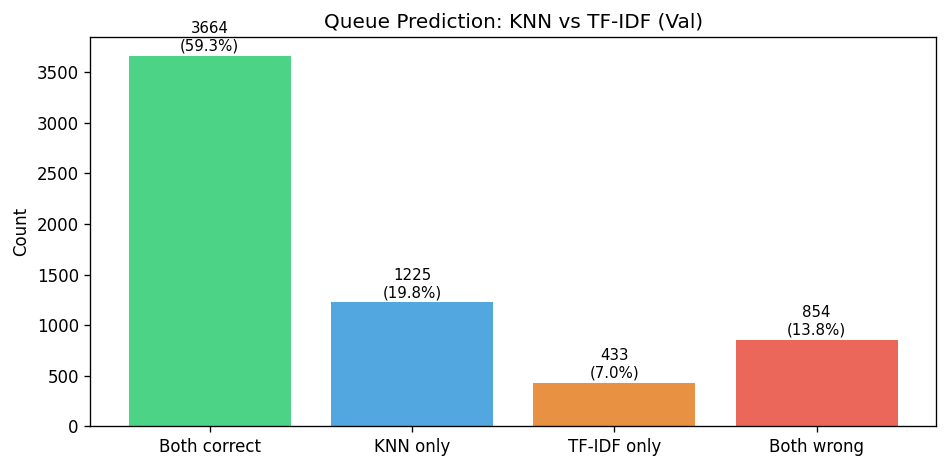

In [52]:
# Venn-like bar chart
if tfidf_pred_val_q is not None:
    cats = ["Both correct", "KNN only", "TF-IDF only", "Both wrong"]
    both_correct = len(val_df_analysis) - len(knn_wrong_tfidf_right) - len(tfidf_wrong_knn_right) - len(both_wrong)
    counts = [both_correct, len(tfidf_wrong_knn_right), len(knn_wrong_tfidf_right), len(both_wrong)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]
    bars = ax.bar(cats, counts, color=colors, alpha=0.85)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f"{count}\n({count/len(val_df_analysis)*100:.1f}%)",
                ha="center", va="bottom", fontsize=9)
    ax.set_title("Queue Prediction: KNN vs TF-IDF (Val)")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "knn_vs_tfidf_venn.png", dpi=150)
    plt.show()

In [53]:
# Examples where KNN wrong but TF-IDF right
print("=== KNN WRONG, TF-IDF RIGHT — sample examples ===")
sample = knn_wrong_tfidf_right.head(5) if tfidf_pred_val_q is not None else pd.DataFrame()
for i, row in sample.iterrows():
    print(f"\n[{i}] True: {row['true_queue']}")
    print(f"  KNN predicted:   {row['knn_pred']}")
    print(f"  TFIDF predicted: {row['tfidf_pred']}")
    text_preview = row['text'][:200].replace('\n', ' ')
    print(f"  Text: {text_preview}...")

=== KNN WRONG, TF-IDF RIGHT — sample examples ===

[4] True: Technical Support
  KNN predicted:   Product Support
  TFIDF predicted: Technical Support
  Text: Urgent: Ongoing System Failures Disrupting EMR/PACS Telehealth Services [SEP] Dear Customer Support Team,\n\nWe are facing repeated system failures that are significantly impairing EMR/PACS integratio...

[13] True: Billing and Payments
  KNN predicted:   Autos & Vehicles/Sales
  TFIDF predicted: Billing and Payments
  Text: Dringende Unterstützung wegen Abrechnungsdifferenz benötigt [SEP] Sehr geehrtes Kundensupport-Team,\n\nich hoffe, diese Nachricht erreicht Sie wohlbehalten. Ich schreibe, um Ihre Aufmerksamkeit auf ei...

[19] True: Returns and Exchanges
  KNN predicted:   Service Outages and Maintenance
  TFIDF predicted: Returns and Exchanges
  Text: Revision of Return and Exchange Workflows [SEP] Sehr geehrtes Kundenservice-Team,\n\nich hoffe, diese Nachricht erreicht Sie wohlbehalten. Ich möchte um eine Aktualisierung der

In [54]:
# Examples where TF-IDF wrong but KNN right
print("=== TF-IDF WRONG, KNN RIGHT — sample examples ===")
sample2 = tfidf_wrong_knn_right.head(5) if tfidf_pred_val_q is not None else pd.DataFrame()
for i, row in sample2.iterrows():
    print(f"\n[{i}] True: {row['true_queue']}")
    print(f"  KNN predicted:   {row['knn_pred']}")
    print(f"  TFIDF predicted: {row['tfidf_pred']}")
    text_preview = row['text'][:200].replace('\n', ' ')
    print(f"  Text: {text_preview}...")

=== TF-IDF WRONG, KNN RIGHT — sample examples ===

[5] True: Customer Service
  KNN predicted:   Customer Service
  TFIDF predicted: Technical Support
  Text: Revise Marketing Firm Framework [SEP] Dear Customer Service Team,\n\nI am reaching out to request modifications to the marketing firm's framework. I wish to incorporate new technologies to broaden our...

[8] True: IT Support
  KNN predicted:   IT Support
  TFIDF predicted: Technical Support
  Text: Network Connectivity Problems Impacting Medical Equipment [SEP] Dear Support Team,\n\nI am writing to report a critical problem affecting several linked healthcare devices on our network. These device...

[14] True: IT Support
  KNN predicted:   IT Support
  TFIDF predicted: Technical Support
  Text: Immediate Attention Needed: Multiple Units Experiencing Connectivity Performance Problems [SEP] Dear Support Team,\n\nI am submitting a report concerning a significant problem impacting several hardwa...

[21] True: Product Support
  KNN 

In [55]:
# Error analysis by queue class — where does KNN struggle?
if tfidf_pred_val_q is not None:
    knn_class_acc = (
        val_df_analysis.groupby("true_queue")["knn_correct"].mean()
        .sort_values()
        .reset_index()
    )
    knn_class_acc.columns = ["queue_class", "knn_acc"]

    tfidf_class_acc = (
        val_df_analysis.groupby("true_queue")["tfidf_correct"].mean()
        .reset_index()
    )
    tfidf_class_acc.columns = ["queue_class", "tfidf_acc"]

    class_compare = knn_class_acc.merge(tfidf_class_acc, on="queue_class")
    class_compare["knn_advantage"] = class_compare["knn_acc"] - class_compare["tfidf_acc"]
    class_compare = class_compare.sort_values("knn_advantage")

    print("Top 5 classes where TF-IDF beats KNN:")
    print(class_compare.head(5).to_string(index=False))
    print("\nTop 5 classes where KNN beats TF-IDF:")
    print(class_compare.tail(5).to_string(index=False))

Top 5 classes where TF-IDF beats KNN:
                        queue_class  knn_acc  tfidf_acc  knn_advantage
               Health/Mental Health 0.888889        1.0      -0.111111
          Home & Garden/Landscaping 0.941176        1.0      -0.058824
IT & Technology/Security Operations 0.942857        1.0      -0.057143
   IT & Technology/Hardware Support 0.948718        1.0      -0.051282
         Beauty & Fitness/Cosmetics 0.961538        1.0      -0.038462

Top 5 classes where KNN beats TF-IDF:
          queue_class  knn_acc  tfidf_acc  knn_advantage
      Human Resources 0.688172   0.440860       0.247312
  Sales and Pre-Sales 0.629032   0.322581       0.306452
           IT Support 0.705773   0.396648       0.309125
Returns and Exchanges 0.765690   0.364017       0.401674
      General Inquiry 0.753425   0.205479       0.547945


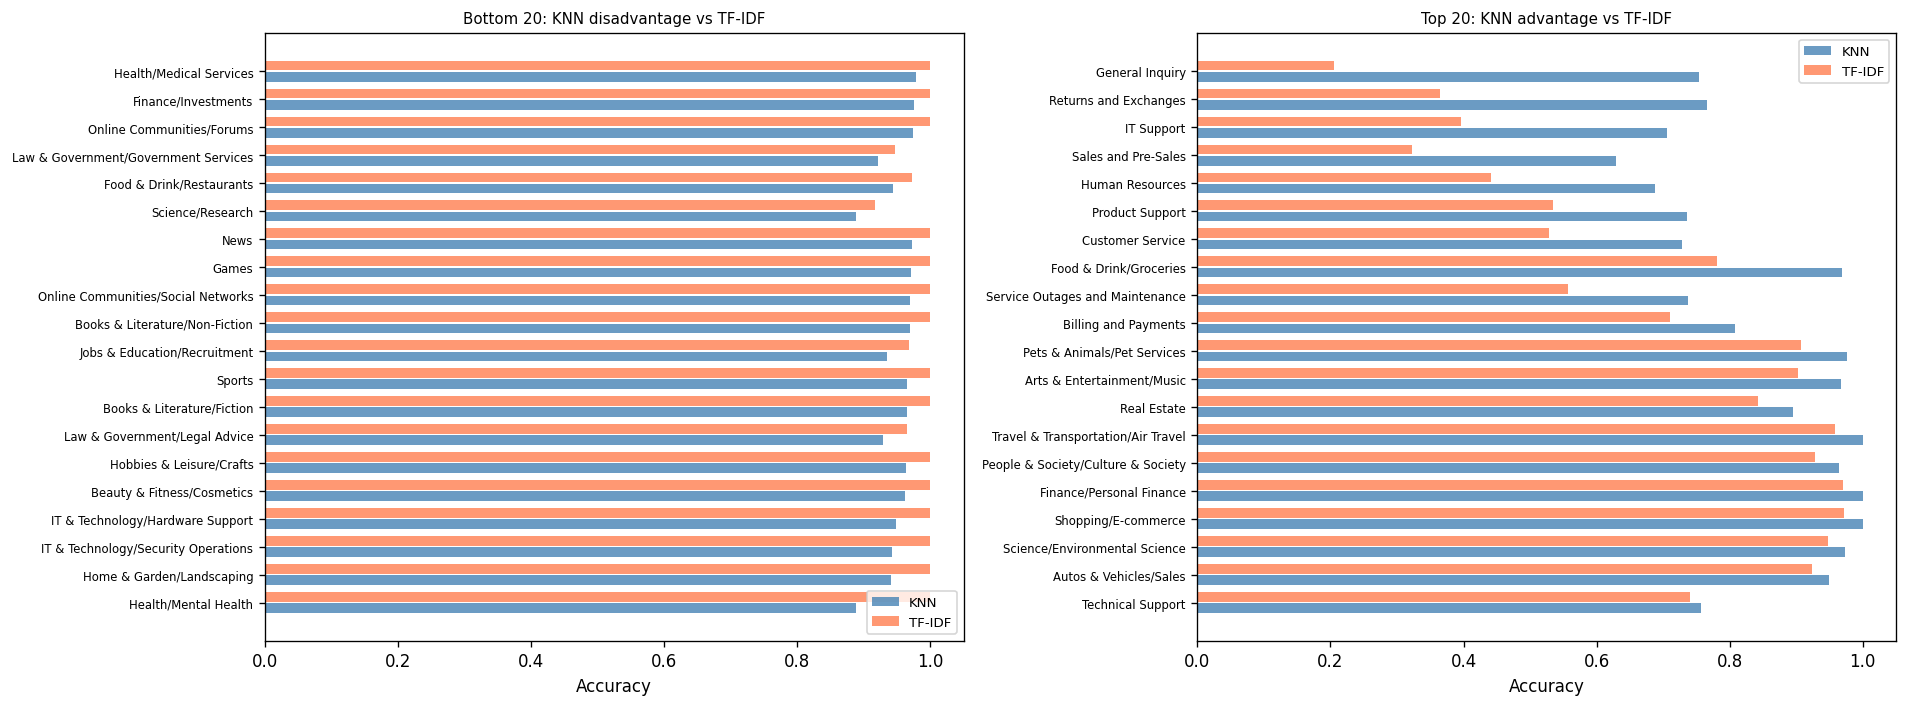

In [56]:
# Plot class-level comparison — bottom 20 and top 20
if tfidf_pred_val_q is not None and len(class_compare) > 0:
    n_show = min(20, len(class_compare))
    bottom_n = class_compare.head(n_show).copy()
    top_n    = class_compare.tail(n_show).copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, data, title in [
        (axes[0], bottom_n, f"Bottom {n_show}: KNN disadvantage vs TF-IDF"),
        (axes[1], top_n,    f"Top {n_show}: KNN advantage vs TF-IDF"),
    ]:
        x = np.arange(len(data))
        ax.barh(x - 0.2, data["knn_acc"],   height=0.35, label="KNN",   color="steelblue", alpha=0.8)
        ax.barh(x + 0.2, data["tfidf_acc"], height=0.35, label="TF-IDF", color="coral",     alpha=0.8)
        ax.set_yticks(x)
        ax.set_yticklabels(data["queue_class"], fontsize=7)
        ax.set_xlabel("Accuracy")
        ax.set_title(title, fontsize=9)
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1.05)

    plt.tight_layout()
    plt.savefig(PLOT_DIR / "knn_vs_tfidf_class_acc.png", dpi=150)
    plt.show()

## 9. Speed Comparison: FlatIP vs IVFFlat

In [57]:
import timeit

query_batch = emb_mini["val"][:500].astype(np.float32)
k = best_k_mini

t_flat = timeit.timeit(lambda: idx_mini_flat.search(query_batch, k), number=5) / 5
t_ivf  = timeit.timeit(lambda: idx_mini_ivf.search(query_batch, k),  number=5) / 5

print(f"FlatIP  : {t_flat*1000:.1f} ms / 500 queries  ({t_flat/500*1000:.3f} ms/query)")
print(f"IVFFlat : {t_ivf*1000:.1f} ms / 500 queries  ({t_ivf/500*1000:.3f} ms/query)")
print(f"Speedup : {t_flat/t_ivf:.1f}x")

FlatIP  : 173.2 ms / 500 queries  (0.346 ms/query)
IVFFlat : 178.8 ms / 500 queries  (0.358 ms/query)
Speedup : 1.0x


## 10. Summary Table

In [58]:
# Build final summary table
summary_rows = []

# TF-IDF baseline (from saved results)
summary_rows.append({
    "model": "TF-IDF LinearSVC", "split": "val",
    "queue_macro_f1": 0.8845, "priority_acc": 0.6941, "type_acc": 0.8865,
    "composite": 0.8562
})
summary_rows.append({
    "model": "TF-IDF LinearSVC", "split": "test",
    "queue_macro_f1": 0.8745, "priority_acc": 0.6863, "type_acc": 0.8912,
    "composite": 0.8488
})

# MiniLM KNN val
m = mini_flat_val[best_k_mini]["metrics"]
summary_rows.append({
    "model": f"MiniLM KNN k={best_k_mini}", "split": "val",
    "queue_macro_f1": m["queue"]["macro_f1"],
    "priority_acc": m["priority"]["accuracy"],
    "type_acc": m["type"]["accuracy"],
    "composite": m["composite_score"]
})

# MiniLM KNN test
m = mini_flat_test[best_k_mini]["metrics"]
summary_rows.append({
    "model": f"MiniLM KNN k={best_k_mini}", "split": "test",
    "queue_macro_f1": m["queue"]["macro_f1"],
    "priority_acc": m["priority"]["accuracy"],
    "type_acc": m["type"]["accuracy"],
    "composite": m["composite_score"]
})

# MPNet KNN val
m = mpnet_flat_val[best_k_mpnet]["metrics"]
summary_rows.append({
    "model": f"MPNet-ML KNN k={best_k_mpnet}", "split": "val",
    "queue_macro_f1": m["queue"]["macro_f1"],
    "priority_acc": m["priority"]["accuracy"],
    "type_acc": m["type"]["accuracy"],
    "composite": m["composite_score"]
})

# MPNet KNN test
m = mpnet_flat_test[best_k_mpnet]["metrics"]
summary_rows.append({
    "model": f"MPNet-ML KNN k={best_k_mpnet}", "split": "test",
    "queue_macro_f1": m["queue"]["macro_f1"],
    "priority_acc": m["priority"]["accuracy"],
    "type_acc": m["type"]["accuracy"],
    "composite": m["composite_score"]
})

# Hybrid val/test
hybrid_val_best = hybrid_val_results[best_alpha]  # just composite

# run val once more to get per-metric
hybrid_val_metrics = hybrid_predict(
    "val", idx_mini_flat, emb_mini["val"],
    labels["train"], labels["val"],
    tfidf_pipelines, texts["val"],
    k=best_k_mini, alpha_tfidf=best_alpha[0], alpha_emb=best_alpha[1]
)
summary_rows.append({
    "model": f"Hybrid MiniLM+TFIDF ({best_alpha[0]}/{best_alpha[1]})", "split": "val",
    "queue_macro_f1": hybrid_val_metrics["queue"]["macro_f1"],
    "priority_acc": hybrid_val_metrics["priority"]["accuracy"],
    "type_acc": hybrid_val_metrics["type"]["accuracy"],
    "composite": hybrid_val_metrics["composite_score"]
})
summary_rows.append({
    "model": f"Hybrid MiniLM+TFIDF ({best_alpha[0]}/{best_alpha[1]})", "split": "test",
    "queue_macro_f1": hybrid_test_mini["queue"]["macro_f1"],
    "priority_acc": hybrid_test_mini["priority"]["accuracy"],
    "type_acc": hybrid_test_mini["type"]["accuracy"],
    "composite": hybrid_test_mini["composite_score"]
})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

  [val] queue     : acc=0.8031  macro_f1=0.9252
  [val] priority  : acc=0.8063  macro_f1=0.8604
  [val] type      : acc=0.9109  macro_f1=0.9055
  [val] composite=0.9052  (alpha_tfidf=0.4, alpha_emb=0.6)
                        model split  queue_macro_f1  priority_acc  type_acc  composite
             TF-IDF LinearSVC   val          0.8845        0.6941    0.8865     0.8562
             TF-IDF LinearSVC  test          0.8745        0.6863    0.8912     0.8488
               MiniLM KNN k=2   val          0.9111        0.8196    0.9053     0.8965
               MiniLM KNN k=2  test          0.9006        0.8166    0.9072     0.8890
             MPNet-ML KNN k=2   val          0.9506        0.8787    0.9475     0.9394
             MPNet-ML KNN k=2  test          0.9503        0.8711    0.9441     0.9375
Hybrid MiniLM+TFIDF (0.4/0.6)   val          0.9252        0.8063    0.9109     0.9052
Hybrid MiniLM+TFIDF (0.4/0.6)  test          0.9140        0.8015    0.9129     0.8970


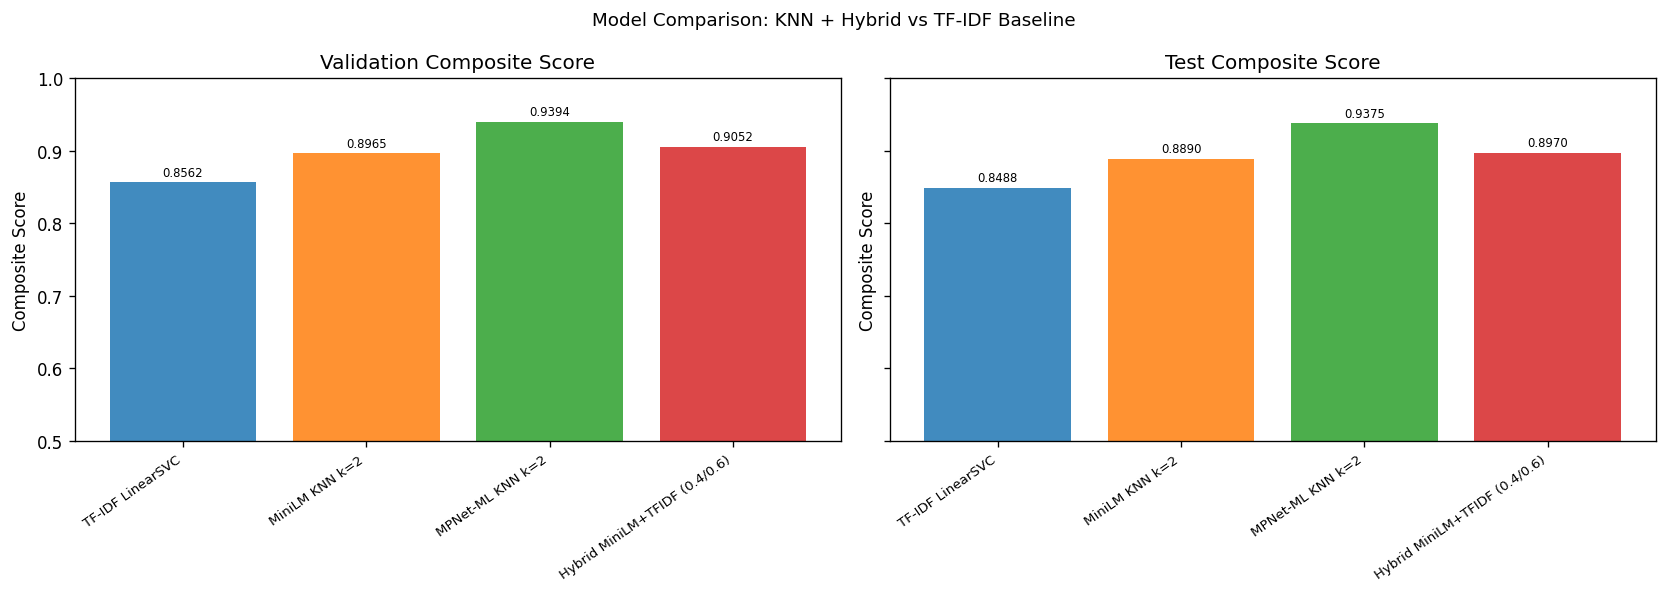

In [59]:
# Final bar plot: composite scores all models
val_summary  = summary_df[summary_df["split"] == "val"]
test_summary = summary_df[summary_df["split"] == "test"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = plt.cm.tab10.colors

for ax, sub, title in [(axes[0], val_summary, "Validation"), (axes[1], test_summary, "Test")]:
    bars = ax.bar(range(len(sub)), sub["composite"], color=colors[:len(sub)], alpha=0.85)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["model"], rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Composite Score")
    ax.set_title(f"{title} Composite Score")
    ax.set_ylim(0.5, 1.0)
    for bar, val in zip(bars, sub["composite"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Model Comparison: KNN + Hybrid vs TF-IDF Baseline", fontsize=11)
plt.tight_layout()
plt.savefig(PLOT_DIR / "knn_final_comparison.png", dpi=150)
plt.show()

## 11. Save Results to JSON

In [60]:
def strip_preds(res_dict):
    """Remove numpy arrays from results for JSON serialization."""
    clean = {}
    for k, v in res_dict.items():
        if isinstance(v, dict):
            clean[k] = strip_preds(v)
        elif isinstance(v, np.ndarray):
            pass  # skip
        else:
            clean[k] = v
    return clean


knn_results = {
    "mini_lm": {
        "model": "sentence-transformers/all-MiniLM-L6-v2",
        "index_type": idx_type_mini_flat,
        "best_k": best_k_mini,
        "val": {
            k: strip_preds(mini_flat_val[k]["metrics"])
            for k in K_VALUES
        },
        "test": strip_preds(mini_flat_test[best_k_mini]["metrics"]),
        "val_ivf": {
            k: strip_preds(mini_ivf_val[k]["metrics"])
            for k in K_VALUES
        },
    },
    "mpnet_ml": {
        "model": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
        "index_type": idx_type_mpnet_flat,
        "best_k": best_k_mpnet,
        "val": {
            k: strip_preds(mpnet_flat_val[k]["metrics"])
            for k in K_VALUES
        },
        "test": strip_preds(mpnet_flat_test[best_k_mpnet]["metrics"]),
    },
    "hybrid_mini_tfidf": {
        "model": "MiniLM + TF-IDF LinearSVC",
        "alpha_tfidf": best_alpha[0],
        "alpha_emb": best_alpha[1],
        "best_k": best_k_mini,
        "val": {
            "queue":     {"macro_f1": hybrid_val_metrics["queue"]["macro_f1"], "accuracy": hybrid_val_metrics["queue"]["accuracy"]},
            "priority":  {"accuracy": hybrid_val_metrics["priority"]["accuracy"]},
            "type":      {"accuracy": hybrid_val_metrics["type"]["accuracy"]},
            "composite_score": hybrid_val_metrics["composite_score"]
        },
        "test": {
            "queue":     {"macro_f1": hybrid_test_mini["queue"]["macro_f1"], "accuracy": hybrid_test_mini["queue"]["accuracy"]},
            "priority":  {"accuracy": hybrid_test_mini["priority"]["accuracy"]},
            "type":      {"accuracy": hybrid_test_mini["type"]["accuracy"]},
            "composite_score": hybrid_test_mini["composite_score"]
        },
        "hybrid_mpnet_test": {
            "queue":     {"macro_f1": hybrid_test_mpnet["queue"]["macro_f1"]},
            "priority":  {"accuracy": hybrid_test_mpnet["priority"]["accuracy"]},
            "type":      {"accuracy": hybrid_test_mpnet["type"]["accuracy"]},
            "composite_score": hybrid_test_mpnet["composite_score"]
        }
    },
    "alpha_sweep_val": {
        str(k): v for k, v in hybrid_val_results.items()
    },
    "embedding_files": {
        "mini_lm_train": str(EMB_DIR / "minilm_train.npy"),
        "mini_lm_val":   str(EMB_DIR / "minilm_val.npy"),
        "mini_lm_test":  str(EMB_DIR / "minilm_test.npy"),
        "mpnet_ml_train": str(EMB_DIR / "mpnet_ml_train.npy"),
        "mpnet_ml_val":   str(EMB_DIR / "mpnet_ml_val.npy"),
        "mpnet_ml_test":  str(EMB_DIR / "mpnet_ml_test.npy"),
    }
}

# Load existing results and merge
if RESULTS_FILE.exists():
    with open(RESULTS_FILE) as f:
        all_results = json.load(f)
else:
    all_results = {}

all_results["knn_embeddings"] = knn_results

with open(RESULTS_FILE, "w") as f:
    json.dump(all_results, f, indent=2, default=str)

print(f"Results saved to {RESULTS_FILE}")
print("\nKey results:")
print(f"  MiniLM KNN (k={best_k_mini}) val  composite: {mini_flat_val[best_k_mini]['metrics']['composite_score']}")
print(f"  MiniLM KNN (k={best_k_mini}) test composite: {mini_flat_test[best_k_mini]['metrics']['composite_score']}")
print(f"  MPNet-ML KNN (k={best_k_mpnet}) val  composite: {mpnet_flat_val[best_k_mpnet]['metrics']['composite_score']}")
print(f"  MPNet-ML KNN (k={best_k_mpnet}) test composite: {mpnet_flat_test[best_k_mpnet]['metrics']['composite_score']}")
print(f"  Hybrid MiniLM+TFIDF val  composite: {hybrid_val_metrics['composite_score']}")
print(f"  Hybrid MiniLM+TFIDF test composite: {hybrid_test_mini['composite_score']}")
print(f"  TF-IDF baseline val  composite: 0.8562")
print(f"  TF-IDF baseline test composite: 0.8488")

Results saved to /kaggle/working/results_tfidf.json

Key results:
  MiniLM KNN (k=2) val  composite: 0.8965
  MiniLM KNN (k=2) test composite: 0.889
  MPNet-ML KNN (k=2) val  composite: 0.9394
  MPNet-ML KNN (k=2) test composite: 0.9375
  Hybrid MiniLM+TFIDF val  composite: 0.9052
  Hybrid MiniLM+TFIDF test composite: 0.897
  TF-IDF baseline val  composite: 0.8562
  TF-IDF baseline test composite: 0.8488


In [61]:
print("\n" + "="*60)
print("DONE. Saved:")
print(f"  Embeddings : {EMB_DIR}/")
print(f"  Plots      : {PLOT_DIR}/knn_*.png")
print(f"  Results    : {RESULTS_FILE}  → key 'knn_embeddings'")
print("="*60)


DONE. Saved:
  Embeddings : /kaggle/working/embeddings/
  Plots      : /kaggle/working/plots/knn_*.png
  Results    : /kaggle/working/results_tfidf.json  → key 'knn_embeddings'
